# Chapter 18 — Fast Radio Bursts & the Transient Radio Sky

!!! info "Before you start"
    **Prerequisites:** Ch 13 (Pulsars) · **Maths Lab:** [Lab B (Matched Filtering)](32_mathslab_matched_filtering.ipynb) · **~50 min** · **Intermediate**

In **Chapter 13** we met the **pulsar**: a rotating neutron star whose broadband
pulse is smeared in time by the **cold-plasma dispersion** of the interstellar
medium, and we learned to *de-disperse* and *fold* to recover it. This chapter
pushes that same machinery to its most extreme and exciting application: the
**fast radio burst (FRB)** — a single, millisecond flash of radio emission from
*another galaxy*, carrying a dispersion measure so large it can only have been
accumulated crossing billions of light-years of intergalactic plasma.

FRBs are, in a sense, "pulsars you only ever see once" (with the twist that some
of them **repeat**). The detection problem is sharper: there is no period to fold
on, so you live or die by a **single-pulse search** — de-disperse at thousands of
trial dispersion measures, run a **matched filter** for the unknown pulse width,
and look for one spike that rises above the noise *and behaves like the sky and
not like your microwave oven*. That last clause is not a joke; it is the central
discipline of the field, and we will end the chapter on it.

### Learning goals

By the end of this chapter you will be able to:

- say what an **FRB** is — millisecond, **extragalactic**, enormous **DM** — and
  how it differs from a pulsar;
- write down the cold-plasma dispersion law $t \propto \mathrm{DM}\cdot\nu^{-2}$
  and read a dispersed burst off a **dynamic spectrum**;
- run a **single-pulse DM search** and read the **S/N-vs-DM "butterfly"** that
  peaks at the true DM;
- explain why a **boxcar matched filter** tuned to the pulse width is the optimal
  detector, and find the best width;
- turn an FRB's **excess DM** into a rough redshift via the **Macquart relation**,
  and say why FRBs probe the universe's **"missing baryons"**;
- apply the **RFI discipline** — the perytons lesson — to tell a real burst from
  interference.

This chapter runs **end-to-end offline** on the base environment. All "data" are
simulated with [`jansky.transients`](../src/jansky/transients.py), the same
de-dispersion engine that backs Chapter 13.

## 1. Orientation — FRBs vs pulsars

A **pulsar** (Chapter 13) is a clock: a beam sweeping past us once per rotation,
period from milliseconds to seconds, sitting *inside our own Galaxy* with a
dispersion measure of tens to a few hundred $\mathrm{pc\,cm^{-3}}$ — the electron
column out to a source a few kpc away. A **fast radio burst** is almost the
opposite:

| | Pulsar | Fast radio burst |
|---|---|---|
| Duration | periodic train, ms–s period | **one** flash, ~ms wide |
| Repeats? | every rotation, forever | mostly **one-off**; some **repeat** |
| Location | Galactic (a few kpc) | **extragalactic** (Gpc) |
| Dispersion measure | tens–hundreds | **hundreds–thousands** $\mathrm{pc\,cm^{-3}}$ |
| Search method | de-disperse **+ fold** on $P$ | **single-pulse** (no period to fold) |

That enormous DM is the headline. The Milky Way can only contribute a few hundred
$\mathrm{pc\,cm^{-3}}$ along most sightlines, so a burst with DM $\sim 1000$ must
have crossed a vast column of **intergalactic** plasma — it is extragalactic, and
its excess DM is a ruler for cosmic distance (Section 5).

### The field, in four papers

- **Lorimer et al. (2007)** — *A Bright Millisecond Radio Burst of Extragalactic
  Origin*, **Science 318, 777**. The **"Lorimer burst"**: a single 30-jansky,
  ~5 ms pulse in archival Parkes data with DM $\approx 375$ — far beyond any
  Galactic contribution. The first FRB, and the seed of the field.
  [ADS](https://ui.adsabs.harvard.edu/abs/2007Sci...318..777L)
- **Thornton et al. (2013)** — *A Population of Fast Radio Bursts at Cosmological
  Distances*, **Science 341, 53**. Four more bursts at high Galactic latitude
  established FRBs as a **real cosmological population**, not a one-off fluke (or
  a peryton — see Section 6).
  [ADS](https://ui.adsabs.harvard.edu/abs/2013Sci...341...53T)
- **Spitler et al. (2016)** — *A Repeating Fast Radio Burst*, **Nature 531, 202**.
  FRB 121102 burst **again** from the same DM and sky position, ruling out a
  purely cataclysmic (one-time, destroy-the-source) origin for *at least some*
  FRBs and opening the door to localisation.
  [ADS](https://ui.adsabs.harvard.edu/abs/2016Natur.531..202S)
- **CHIME/FRB Collaboration (2020)** — *A Bright Millisecond-Duration Radio Burst
  from a Galactic Magnetar*, **Nature 587, 54** (with STARE2, Bochenek et al.
  2020). An FRB-like burst from **SGR 1935+2154**, a magnetar **inside the Milky
  Way** — the first FRB source caught at home, tying *at least some* FRBs to
  **magnetars**.
  [ADS](https://ui.adsabs.harvard.edu/abs/2020Natur.587...54C)

See the course's
[papers timeline](../docs/papers-timeline.md) for these entries in context.

## Setup

We import the de-dispersion toolkit from `jansky.transients` — **the same module
used in Chapter 13** — and the course plotting style. We **do not re-implement**
dispersion or de-dispersion: every numerical step below calls a helper from that
module. We seed every random draw so the chapter is reproducible.

The helpers we use:

- `dispersion_delay(dm, f_lo, f_hi)` — the cold-plasma delay between two
  frequencies (the $\nu^{-2}$ law);
- `disperse_pulse(...)` — build a synthetic dynamic spectrum with one dispersed
  pulse;
- `dedisperse(dynspec, freqs, dm, dt)` — de-disperse at a trial DM and sum to a
  time series;
- `dm_search(...)` / `DMSearchResult` — the single-pulse DM search (the
  "butterfly");
- `boxcar_snr(series, widths)` — matched-filter for the unknown pulse width;
- `macquart_redshift(dm_excess)` — rough redshift from excess DM;
- `DM_CONST` — the dispersion constant $k_\mathrm{DM}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from jansky.plotting import use_jansky_style, show_image
from jansky.transients import (
    DM_CONST,
    dispersion_delay,
    disperse_pulse,
    dedisperse,
    dm_search,
    DMSearchResult,
    boxcar_snr,
    macquart_redshift,
)

use_jansky_style()
rng = np.random.default_rng(18)  # one seed for the whole chapter

print(f"dispersion constant k_DM = {DM_CONST:.4g} MHz^2 cm^3 pc^-1 s")

dispersion constant k_DM = 4149 MHz^2 cm^3 pc^-1 s


## 2. A dispersed burst

The raw data product is a **dynamic spectrum** (waterfall): intensity as a
function of **time** (rows) and **frequency** (channels). We simulate one CHIME-
like band, **400–800 MHz**, sampled in milliseconds, containing a single burst at
**DM = 500 $\mathrm{pc\,cm^{-3}}$** — a plausibly extragalactic value.

The cold-plasma **dispersion law** sets where the pulse lands in each channel.
Relative to the top of the band, the delay at frequency $\nu$ is

$$
\Delta t(\nu) \;=\; k_\mathrm{DM}\,\mathrm{DM}\,
\left(\nu^{-2} - \nu_\mathrm{hi}^{-2}\right),
\qquad
k_\mathrm{DM} \approx 4148.8\ \mathrm{MHz^2\,cm^3\,pc^{-1}\,s},
$$

with $\nu$ in MHz and DM in $\mathrm{pc\,cm^{-3}}$. The lower frequencies arrive
*later*, so the burst traces a **curved $\nu^{-2}$ sweep** down the band. Let us
first compute that sweep with `dispersion_delay`, then build the waterfall with
`disperse_pulse`.

In [2]:
# --- Observation parameters ------------------------------------------------
f_lo, f_hi = 400.0, 800.0  # band edges [MHz]  (CHIME-like)
n_chan = 256  # frequency channels
n_time = 1024  # time samples
dt = 1.0e-3  # sampling interval [s]  -> 1 ms
DM_true = 500.0  # true dispersion measure [pc cm^-3]

# Channel centre frequencies (descending: top channel = highest frequency).
freqs = np.linspace(f_hi, f_lo, n_chan)

# The dispersion sweep across the FULL band, from dispersion_delay():
sweep_total = dispersion_delay(DM_true, f_lo, f_hi)  # seconds, bottom vs top
print(f"DM = {DM_true:.0f} pc cm^-3")
print(
    f"dispersion delay across {f_lo:.0f}-{f_hi:.0f} MHz: "
    f"{sweep_total * 1e3:.1f} ms  ({sweep_total / dt:.0f} samples)"
)

# Place the burst's high-frequency arrival early so the whole sweep fits in frame.
t0 = 60  # arrival sample index at the top of the band
dynspec = disperse_pulse(
    n_time=n_time,
    freqs_mhz=freqs,
    dm=DM_true,
    dt=dt,
    t0_index=t0,
    width_samples=3.0,  # intrinsic pulse width ~3 ms
    amplitude=12.0,  # peak amplitude in units of the noise sigma
    noise=1.0,
    seed=18,  # reproducible
)
print("dynamic spectrum shape (time, freq):", dynspec.shape)

DM = 500 pc cm^-3
dispersion delay across 400-800 MHz: 9723.8 ms  (9724 samples)
dynamic spectrum shape (time, freq): (1024, 256)


Below, the waterfall (frequency on the y-axis, time on the x-axis) shows the
burst as a **curved streak**: a pulse that arrives at the top of the band first
and sweeps down to lower frequencies, exactly the $\nu^{-2}$ shape. The dashed
curve is the *predicted* arrival time per channel from `dispersion_delay` — it
lies right on the streak, confirming the burst obeys the cold-plasma law. (A
local interference blip would be **vertical**; a real burst is **curved**. Hold
that thought for Section 6.)

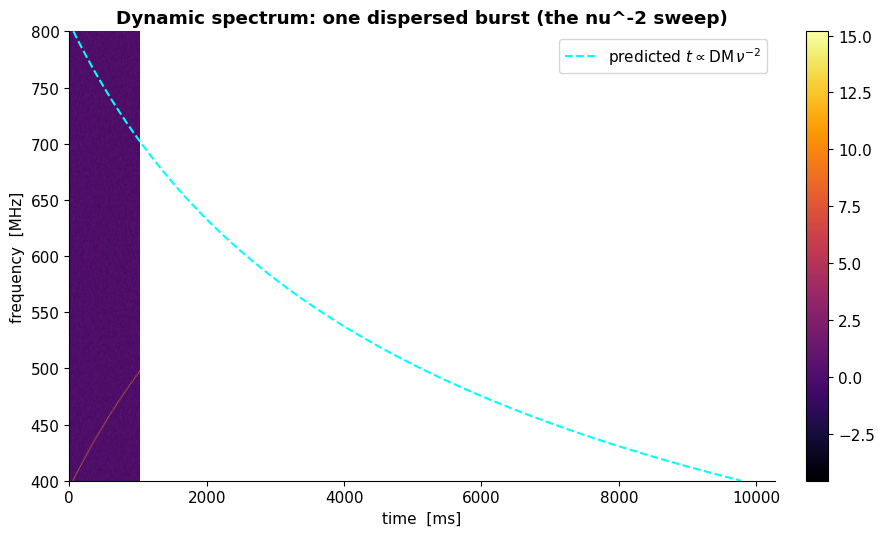

Top of band (800 MHz) arrives at  ~60 ms
Bottom of band (400 MHz) arrives at ~9784 ms
=> the burst is smeared over ~9724 ms of the record by dispersion alone.


In [3]:
# Predicted arrival time (sample index) per channel, from dispersion_delay():
arrival_idx = t0 + np.array([dispersion_delay(DM_true, f, f_hi) / dt for f in freqs])

fig, ax = plt.subplots(figsize=(9, 5.5))
# show_image displays the (freq, time) waterfall; transpose so freq is the y-axis.
extent = [0, n_time * dt * 1e3, f_lo, f_hi]  # x = time [ms], y = freq [MHz]
show_image(
    dynspec.T,
    ax=ax,
    title="Dynamic spectrum: one dispersed burst (the nu^-2 sweep)",
    aspect="auto",
    extent=extent,
)
ax.plot(
    arrival_idx * dt * 1e3,
    freqs,
    ls="--",
    lw=1.5,
    color="cyan",
    label=r"predicted $t \propto \mathrm{DM}\,\nu^{-2}$",
)
ax.set_xlabel("time  [ms]")
ax.set_ylabel("frequency  [MHz]")
ax.grid(False)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Annotate the delay across the band.
print(f"Top of band (800 MHz) arrives at  ~{t0 * dt * 1e3:.0f} ms")
print(f"Bottom of band (400 MHz) arrives at ~{(t0 + sweep_total / dt) * dt * 1e3:.0f} ms")
print(
    f"=> the burst is smeared over ~{sweep_total * 1e3:.0f} ms of the record by dispersion alone."
)

## 3. The DM search — the "butterfly"

For a pulsar we knew the DM (or searched a grid and then *folded*). For a one-off
FRB there is **no period to fold on** — we get exactly one pulse. So the detection
statistic is the **single-pulse search**: de-disperse the waterfall at a grid of
**trial DMs**, sum over frequency, and record the **peak S/N** of the resulting
time series. At the *true* DM the channels line up and the summed pulse spikes; at
a *wrong* DM the residual sweep re-smears it and the S/N drops. The resulting
**S/N-vs-DM curve peaks sharply at the true DM** — its shape, broad wings rising
to a sharp central peak, is universally called the **"butterfly."**

`dm_search` does exactly this, calling `dedisperse` under the hood at each trial
DM. Let us run it over a grid bracketing the true value.

In [4]:
dm_trials = np.linspace(0.0, 1000.0, 401)  # trial DMs [pc cm^-3]
result = dm_search(dynspec, freqs, dt, dm_trials)

assert isinstance(result, DMSearchResult)
print(f"best-fit DM : {result.best_dm:.1f} pc cm^-3   (true = {DM_true:.0f})")
print(f"peak S/N    : {result.best_snr:.1f}")

best-fit DM : 500.0 pc cm^-3   (true = 500)
peak S/N    : 48.2


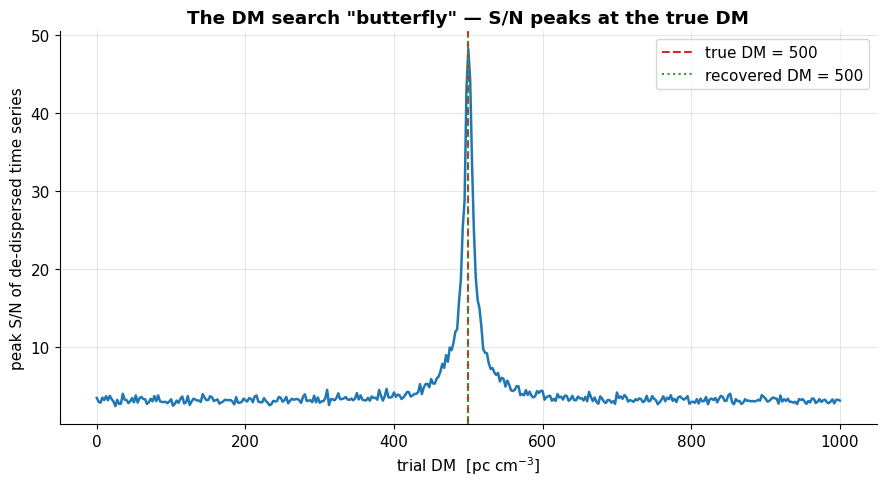

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(result.dms, result.snr, lw=1.8, color="#1f77b4")
ax.axvline(DM_true, color="#d62728", ls="--", label=f"true DM = {DM_true:.0f}")
ax.axvline(
    result.best_dm, color="#2ca02c", ls=":", lw=1.5, label=f"recovered DM = {result.best_dm:.0f}"
)
ax.set_xlabel(r"trial DM  [pc cm$^{-3}$]")
ax.set_ylabel("peak S/N of de-dispersed time series")
ax.set_title('The DM search "butterfly" — S/N peaks at the true DM')
ax.legend()
plt.tight_layout()
plt.show()

Now make the payoff concrete: de-disperse at the **right** DM and at a
**wrong** DM with `dedisperse`, and compare the summed time series. At the true
DM the pulse **snaps into a sharp spike**; at the wrong DM the leftover sweep
**smears it into a low, broad bump** that barely clears the noise.

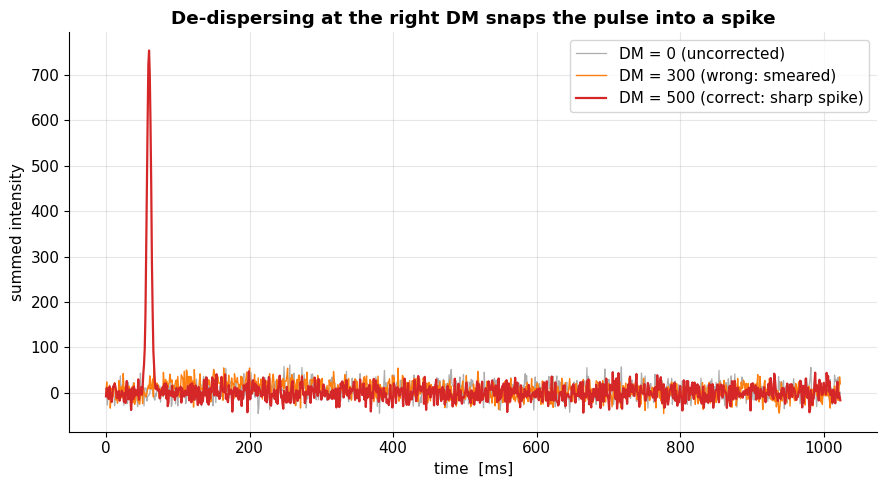

In [6]:
ts_right = dedisperse(dynspec, freqs, DM_true, dt)  # correct DM
ts_wrong = dedisperse(dynspec, freqs, DM_true - 200, dt)  # 200 too low
ts_zero = dedisperse(dynspec, freqs, 0.0, dt)  # no de-dispersion

t_ms = np.arange(n_time) * dt * 1e3

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_ms, ts_zero, lw=0.9, color="#999999", alpha=0.8, label="DM = 0 (uncorrected)")
ax.plot(t_ms, ts_wrong, lw=1.0, color="#ff7f0e", label=f"DM = {DM_true - 200:.0f} (wrong: smeared)")
ax.plot(t_ms, ts_right, lw=1.6, color="#d62728", label=f"DM = {DM_true:.0f} (correct: sharp spike)")
ax.set_xlabel("time  [ms]")
ax.set_ylabel("summed intensity")
ax.set_title("De-dispersing at the right DM snaps the pulse into a spike")
ax.legend()
plt.tight_layout()
plt.show()

### The same search on a real filterbank

The butterfly above ran on a pulse we *injected*. Now point the **exact same**
`dm_search` at a **real** SIGPROC filterbank — the `your` project's example
L-band recording (registered in `jansky.data`), which contains a genuine
dispersed burst. We read it with `your` (the optional `pulsar` extra), flatten
the receiver bandpass, and search trial DMs from 0 to 1000 pc cm⁻³. The S/N-vs-DM
curve peaks **far from DM = 0**, and de-dispersing there snaps a real burst out of
the noise — the same physics and the same code, now on real bytes.


336 channels, 5120 samples, 1465-1130 MHz, 1.27 ms/sample
DM search: best DM = 474 pc/cm^3, peak S/N = 13.3  (vs 3.4 at DM=0)


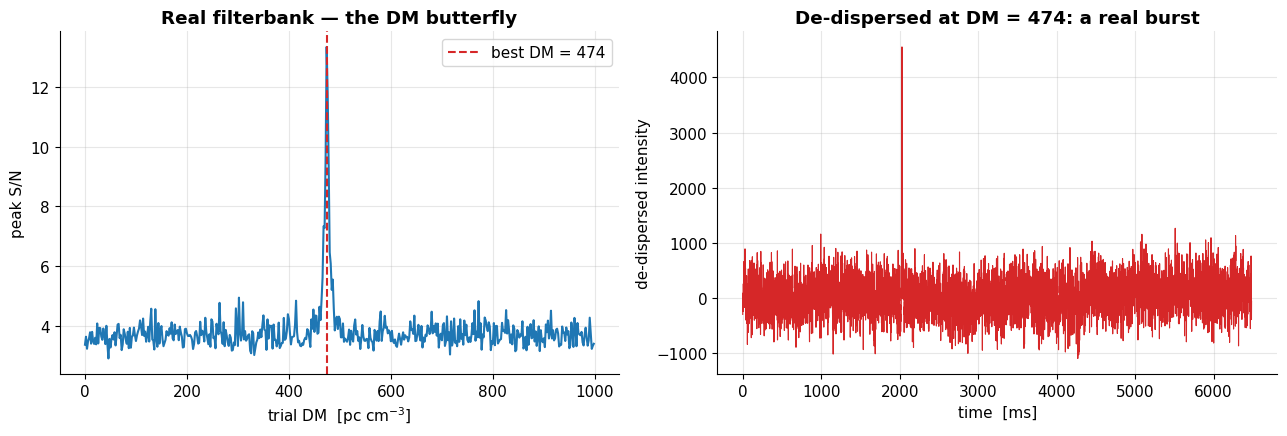

In [7]:
# The SAME single-pulse DM search, now on a REAL filterbank. The `your` project's
# example L-band recording (registered in jansky.data) contains a genuine dispersed
# burst. Guarded behind the `pulsar` extra + a one-time ~1.6 MB download.
try:
    from your import Your

    from jansky import data

    yr = Your(str(data.fetch("filterbank-example")))
    hdr = yr.your_header
    real = yr.get_data(0, hdr.nspectra).astype(float)  # (time, channel)
    real_freqs = hdr.fch1 + hdr.foff * np.arange(hdr.nchans)  # MHz (descending)
    real = real - np.median(real, axis=0, keepdims=True)  # flatten the bandpass

    real_dms = np.arange(0.0, 1000.0, 2.0)
    res_real = dm_search(real, real_freqs, hdr.tsamp, real_dms)
    ts_best = dedisperse(real, real_freqs, res_real.best_dm, hdr.tsamp)
    t_axis = np.arange(real.shape[0]) * hdr.tsamp

    print(
        f"{hdr.nchans} channels, {real.shape[0]} samples, "
        f"{real_freqs[0]:.0f}-{real_freqs[-1]:.0f} MHz, {hdr.tsamp * 1e3:.2f} ms/sample"
    )
    print(
        f"DM search: best DM = {res_real.best_dm:.0f} pc/cm^3, "
        f"peak S/N = {res_real.best_snr:.1f}  (vs {res_real.snr[0]:.1f} at DM=0)"
    )

    fig, (axb, axt) = plt.subplots(1, 2, figsize=(13, 4.5))
    axb.plot(res_real.dms, res_real.snr, color="#1f77b4")
    axb.axvline(
        res_real.best_dm, color="#d62728", ls="--", label=f"best DM = {res_real.best_dm:.0f}"
    )
    axb.set_xlabel(r"trial DM  [pc cm$^{-3}$]")
    axb.set_ylabel("peak S/N")
    axb.set_title("Real filterbank — the DM butterfly")
    axb.legend()

    axt.plot(t_axis * 1e3, ts_best, color="#d62728", lw=0.8)
    axt.set_xlabel("time  [ms]")
    axt.set_ylabel("de-dispersed intensity")
    axt.set_title(f"De-dispersed at DM = {res_real.best_dm:.0f}: a real burst")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"(Real filterbank path skipped: {type(exc).__name__}: {exc})")
    print(
        "Install the `pulsar` extra (`uv sync --extra pulsar`) and re-run "
        "(needs a one-time ~1.6 MB download)."
    )

## 4. Matched filtering for the pulse width

We found *where* (in DM) the pulse is. But how wide is it? FRBs span sub-
millisecond to tens of milliseconds, and we usually **don't know the width in
advance**. The optimal detector for a top-hat pulse of width $w$ buried in white
noise is a **boxcar matched filter** of the *same* width $w$: convolving the time
series with a normalised boxcar averages down the noise over exactly the pulse's
extent while capturing all of its signal.

- Too **narrow** a boxcar: you miss part of the pulse's energy → lower S/N.
- Too **wide** a boxcar: you sweep in extra noise samples → lower S/N.
- **Matched** (boxcar width ≈ pulse width): maximum S/N.

So in practice you try a **ladder of boxcar widths** and keep the best. The
`boxcar_snr` helper does exactly that, returning the best S/N, the matching width,
and the peak sample. We run it on the correctly de-dispersed time series.

In [8]:
widths = np.array([1, 2, 3, 4, 6, 8, 12, 16, 24, 32])  # trial boxcar widths [samples]
best_snr, best_w, peak_idx = boxcar_snr(ts_right, widths)

print(f"best boxcar width : {best_w} samples  (~{best_w * dt * 1e3:.0f} ms)")
print(f"detection S/N     : {best_snr:.1f}")
print(f"peak at sample    : {peak_idx}  (t = {peak_idx * dt * 1e3:.0f} ms)")

# Scan all widths to see the S/N-vs-width curve (each call matches one width).
snr_vs_width = np.array([boxcar_snr(ts_right, [w])[0] for w in widths])

best boxcar width : 8 samples  (~8 ms)
detection S/N     : 104.0
peak at sample    : 60  (t = 60 ms)


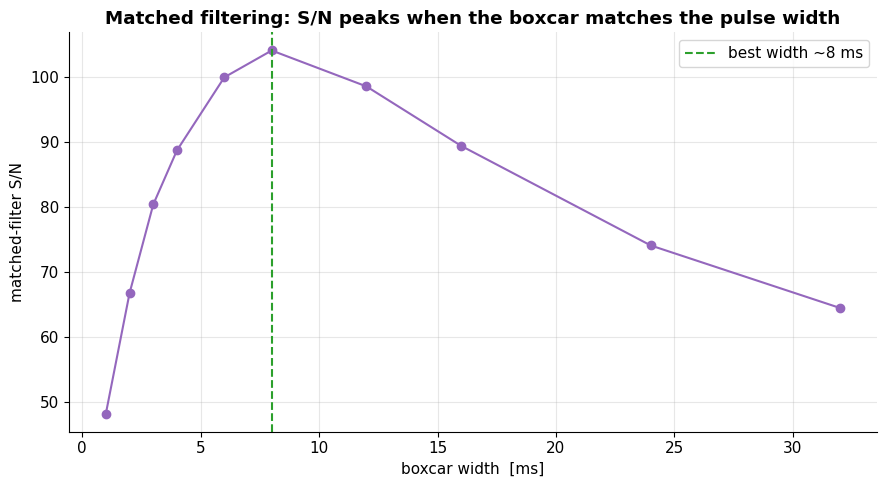

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(widths * dt * 1e3, snr_vs_width, "o-", color="#9467bd")
ax.axvline(
    best_w * dt * 1e3, color="#2ca02c", ls="--", label=f"best width ~{best_w * dt * 1e3:.0f} ms"
)
ax.set_xlabel("boxcar width  [ms]")
ax.set_ylabel("matched-filter S/N")
ax.set_title("Matched filtering: S/N peaks when the boxcar matches the pulse width")
ax.legend()
plt.tight_layout()
plt.show()

## 5. From DM to distance — the Macquart relation

The total observed DM of an FRB is a **sum of contributions** along the sightline:

$$
\mathrm{DM_{obs}} \;=\;
\underbrace{\mathrm{DM_{MW}}}_{\text{Milky Way}} \;+\;
\underbrace{\mathrm{DM_{cosmic}}(z)}_{\text{intergalactic}} \;+\;
\underbrace{\frac{\mathrm{DM_{host}}}{1+z}}_{\text{host galaxy}}.
$$

The Milky Way part we estimate from an electron-density model (NE2001 / YMW16);
the host part is poorly known and we usually fold it into the error budget. What
is left, the **cosmic** part, grows roughly **linearly with redshift** — the
**Macquart relation** (Macquart et al. 2020):

$$
\langle \mathrm{DM_{cosmic}} \rangle \;\approx\; 900\,z\ \ \mathrm{pc\,cm^{-3}}
\quad\Longrightarrow\quad
z \;\approx\; \frac{\mathrm{DM_{excess}}}{900}.
$$

This is the basis for FRBs as a **cosmic-baryon probe**: the cosmic DM counts the
*ionised electrons* the burst crossed, i.e. the diffuse intergalactic baryons.
For decades roughly half of the universe's ordinary (baryonic) matter at low
redshift was unaccounted for at any one wavelength — the **"missing baryons."**
Macquart et al. showed FRB DMs add up to the cosmologically expected baryon
density, **locating the missing baryons** in the diffuse intergalactic medium.

Let us turn our burst's DM into a rough redshift with `macquart_redshift`, after
subtracting a Milky Way contribution.

In [10]:
DM_obs = DM_true  # our recovered DM [pc cm^-3]
DM_MW = 80.0  # assumed Milky Way contribution (NE2001-like)
DM_excess = DM_obs - DM_MW  # extragalactic part (cosmic + host)

z_est = macquart_redshift(DM_excess)  # rough redshift via DM_excess / 900

print(f"observed DM        : {DM_obs:.0f} pc cm^-3")
print(f"Milky Way DM (est) : {DM_MW:.0f} pc cm^-3")
print(f"excess (extragal.) : {DM_excess:.0f} pc cm^-3")
print(f"rough redshift z   : {z_est:.2f}")
print()
print("CAVEAT: order-of-magnitude only. The Macquart relation has large")
print("sightline-to-sightline scatter, and an unknown host-galaxy DM can bias")
print("z high. A real redshift needs an optical host identification (e.g. the")
print("z = 0.193 host of the repeater FRB 121102; Tendulkar et al. 2017).")

observed DM        : 500 pc cm^-3
Milky Way DM (est) : 80 pc cm^-3
excess (extragal.) : 420 pc cm^-3
rough redshift z   : 0.47

CAVEAT: order-of-magnitude only. The Macquart relation has large
sightline-to-sightline scatter, and an unknown host-galaxy DM can bias
z high. A real redshift needs an optical host identification (e.g. the
z = 0.193 host of the repeater FRB 121102; Tendulkar et al. 2017).


To see the scatter for yourself, sweep the assumed host/Milky-Way budget and
watch the inferred redshift move — the same observed DM maps to a *range* of
redshifts depending on what you subtract. This is why FRB cosmology demands many
sightlines (to average down the scatter) and, ideally, host localisations.

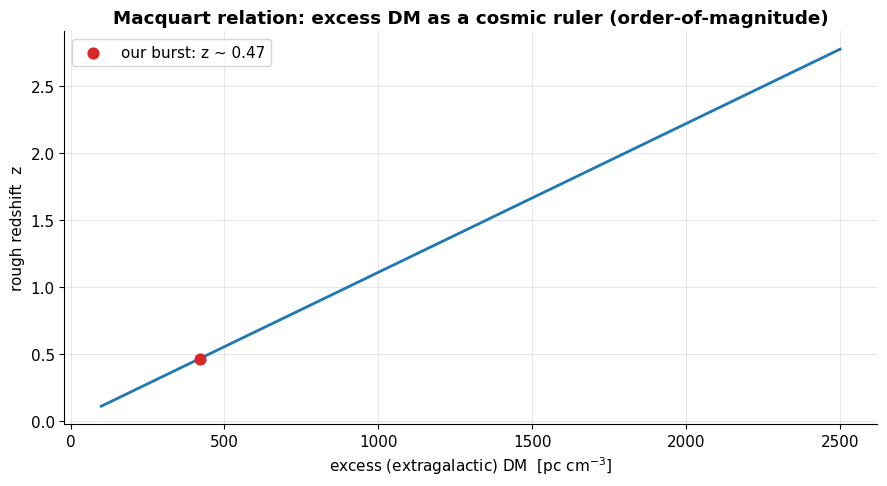

In [11]:
dm_excess_grid = np.linspace(100, 2500, 200)
z_grid = np.array([macquart_redshift(d) for d in dm_excess_grid])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dm_excess_grid, z_grid, lw=2.0, color="#1f77b4")
ax.scatter(
    [DM_excess], [z_est], color="#d62728", zorder=5, s=60, label=f"our burst: z ~ {z_est:.2f}"
)
ax.set_xlabel(r"excess (extragalactic) DM  [pc cm$^{-3}$]")
ax.set_ylabel("rough redshift  z")
ax.set_title("Macquart relation: excess DM as a cosmic ruler (order-of-magnitude)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. RFI vs astrophysical — the discipline of not fooling yourself

This is the most important section in the chapter, and the easiest to skip.
**Most "bursts" your pipeline finds are not from space.** The classic cautionary
tale lives in the course's
[field notes](../docs/field-notes.md): for **17 years** the Parkes telescope
recorded mysterious sub-second signals called **"perytons."** They were eventually
traced to **microwave ovens** on site — opening the oven door mid-cycle let the
magnetron leak a brief burst as the interlock cut power. Seventeen years of a
"new astrophysical phenomenon" that was really lunch.

How do you tell a real FRB from a peryton or any other RFI? Three discriminators,
all of which our simulation lets us *show*:

1. **A real burst disperses as $\nu^{-2}$.** Cold-plasma dispersion is a precise,
   single-parameter law. A genuine astrophysical pulse sweeps through the band on
   a $\nu^{-2}$ curve and peaks **sharply at one DM** in the butterfly. Most RFI
   is **broadband-simultaneous** (a vertical line in the waterfall) or follows
   *no* dispersion law — so it peaks at **DM = 0**, or smears into a broad,
   structureless butterfly with no sharp maximum.
2. **A real source behaves like the sky.** A cosmic source rises and sets with
   **sidereal** time; it appears where the telescope points. Your kitchen does
   not. If a "source" only ever shows up during business hours, or always at the
   same azimuth, suspect the ground.
3. **A real source is a point on the sky.** At Parkes, the decisive clue that the
   FRBs were astrophysical (and the perytons local) was that **FRBs saturate only
   some feeds** of the multibeam receiver — they are point sources entering
   through the main beam — whereas a nearby local source **floods all feeds at
   once**. Always ask: *what would a local source look like in my data?*

Let us demonstrate discriminator (1). We inject a **non-dispersed RFI blip** — a
burst that appears in all channels at the *same* time (DM = 0, a vertical streak)
— and run the **same DM search**. A real FRB's butterfly peaks at its true DM;
the RFI's "butterfly" peaks at **DM = 0** and falls away, betraying that it never
dispersed.

In [12]:
# Build an RFI blip: bright in every channel at the SAME time sample (DM = 0),
# i.e. a vertical streak. disperse_pulse with dm=0 does exactly this.
rfi = disperse_pulse(
    n_time=n_time,
    freqs_mhz=freqs,
    dm=0.0,
    dt=dt,
    t0_index=400,
    width_samples=3.0,
    amplitude=12.0,
    noise=1.0,
    seed=99,
)

res_frb = dm_search(dynspec, freqs, dt, dm_trials)  # the real (dispersed) burst
res_rfi = dm_search(rfi, freqs, dt, dm_trials)  # the non-dispersed RFI blip

print(f"real FRB : butterfly peaks at DM = {res_frb.best_dm:.0f}  (S/N {res_frb.best_snr:.1f})")
print(f"RFI blip : butterfly peaks at DM = {res_rfi.best_dm:.0f}  (S/N {res_rfi.best_snr:.1f})")
print("-> the RFI peaks at DM~0: it never dispersed, so it is not from the cold ISM/IGM.")

real FRB : butterfly peaks at DM = 500  (S/N 48.2)
RFI blip : butterfly peaks at DM = 0  (S/N 193.6)
-> the RFI peaks at DM~0: it never dispersed, so it is not from the cold ISM/IGM.


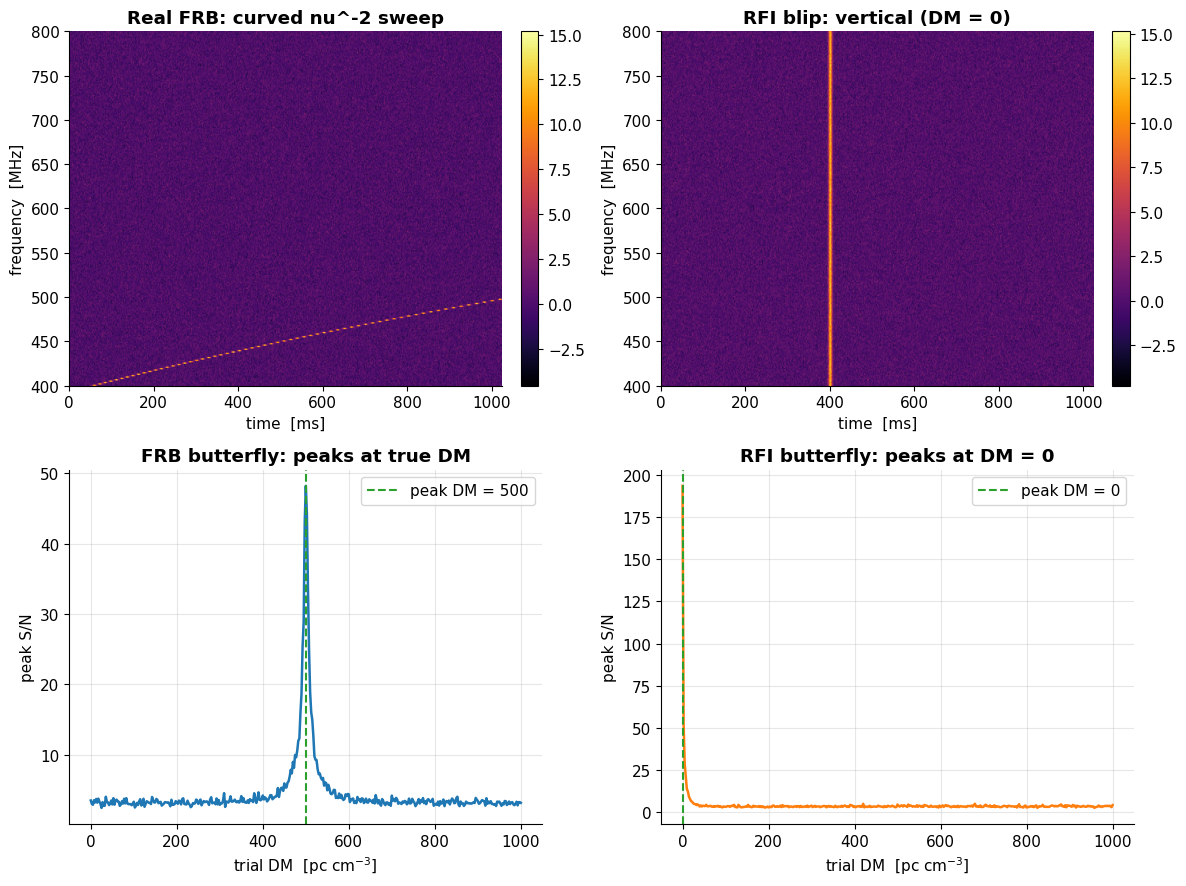

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Top row: the two waterfalls.
for ax, data, ttl in zip(
    axes[0],
    [dynspec, rfi],
    ["Real FRB: curved nu^-2 sweep", "RFI blip: vertical (DM = 0)"],
):
    show_image(data.T, ax=ax, title=ttl, aspect="auto", extent=extent)
    ax.set_xlabel("time  [ms]")
    ax.set_ylabel("frequency  [MHz]")
    ax.grid(False)

# Bottom row: the two butterflies.
for ax, res, color, ttl in zip(
    axes[1],
    [res_frb, res_rfi],
    ["#1f77b4", "#ff7f0e"],
    ["FRB butterfly: peaks at true DM", "RFI butterfly: peaks at DM = 0"],
):
    ax.plot(res.dms, res.snr, lw=1.8, color=color)
    ax.axvline(res.best_dm, color="#2ca02c", ls="--", label=f"peak DM = {res.best_dm:.0f}")
    ax.set_xlabel(r"trial DM  [pc cm$^{-3}$]")
    ax.set_ylabel("peak S/N")
    ax.set_title(ttl)
    ax.legend()

plt.tight_layout()
plt.show()

**Read the figure.** The left column is a real burst: a curved sweep whose
butterfly peaks at the true DM. The right column is RFI: a vertical streak whose
"butterfly" peaks at **DM = 0** and slides downhill — it never obeyed the
cold-plasma law. A DM-vs-0 peak, plus the sky-behaviour and point-source checks
above, is how the field keeps from rediscovering the microwave oven.

### Repeaters vs one-offs

One more astrophysical discriminator worth knowing. Most FRBs are seen **once**;
a minority **repeat** (FRB 121102, Spitler et al. 2016; and many since). A
repeater hands you a gift: it always comes from the **same DM and sky position**,
so you can stare, accumulate many bursts, and **localise** it to a host galaxy —
which is how the first FRB redshift was measured. The CHIME/STARE2 magnetar burst
(2020) showed that *at least some* FRBs come from **magnetars**, though whether
one mechanism explains both repeaters and one-offs is still open.

## 7. Try it yourself

Three exercises, all runnable offline with `jansky.transients`. Each reuses the
machinery above — change a parameter and watch the search respond.

### Exercise 1 — Vary the DM, width, and S/N

Rebuild the burst with a **different DM** (try 200, or 1500), a **different
width** (`width_samples`), or a **lower amplitude** (closer to the noise), then
re-run `dm_search`. How sharp is the butterfly peak as the burst gets fainter? At
what amplitude does the recovered DM start to wander off the true value? (Make a
wide DM grid so the true value is bracketed.)

injected DM 1500  ->  recovered DM 1495  (S/N 12.2)


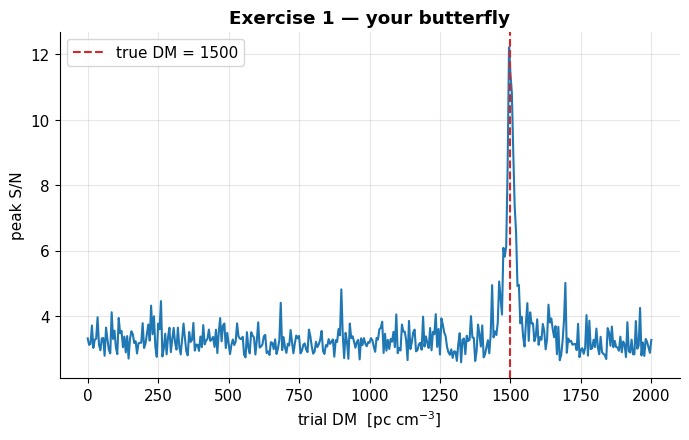

In [14]:
# TODO: change DM_x, width_x, amp_x and re-run. How low can amp_x go before
#       the butterfly peak no longer lands on DM_x?
DM_x = 1500.0  # try 200, 500, 1500
width_x = 2.0  # pulse width in samples
amp_x = 8.0  # peak amplitude (lower = fainter = harder)

dynspec_x = disperse_pulse(
    n_time=n_time,
    freqs_mhz=freqs,
    dm=DM_x,
    dt=dt,
    t0_index=40,
    width_samples=width_x,
    amplitude=amp_x,
    noise=1.0,
    seed=7,
)
grid_x = np.linspace(0, 2000, 401)
res_x = dm_search(dynspec_x, freqs, dt, grid_x)
print(f"injected DM {DM_x:.0f}  ->  recovered DM {res_x.best_dm:.0f}  (S/N {res_x.best_snr:.1f})")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(res_x.dms, res_x.snr, color="#1f77b4")
ax.axvline(DM_x, color="#d62728", ls="--", label=f"true DM = {DM_x:.0f}")
ax.set_xlabel(r"trial DM  [pc cm$^{-3}$]")
ax.set_ylabel("peak S/N")
ax.set_title("Exercise 1 — your butterfly")
ax.legend()
plt.show()

<details>
<summary>Solution</summary>

**How sharp is the peak, and when does the DM wander?** The butterfly's
*sharpness* is set by the burst, not by the noise: a high-DM, narrow burst sweeps
across many channels, so even a small DM error re-smears it badly and the S/N
falls away steeply on either side. Lowering the amplitude does **not** broaden the
peak — it lowers the whole curve toward the noise floor until the true peak no
longer stands above the largest *noise* spike on the grid. At that point the
recovered DM jumps to a random trial value: the search has "lost lock."

Run the supplied grid (`grid_x = np.linspace(0, 2000, 401)`, a 5 pc cm⁻³ step) at
`DM_x = 1500`, `width_x = 2`, and sweep the amplitude:

```python
DM_x, width_x = 1500.0, 2.0
grid_x = np.linspace(0, 2000, 401)
for amp in [8.0, 4.0, 3.0, 2.6, 2.5, 2.0]:
    ds = disperse_pulse(n_time=n_time, freqs_mhz=freqs, dm=DM_x, dt=dt,
                        t0_index=40, width_samples=width_x,
                        amplitude=amp, noise=1.0, seed=7)
    r = dm_search(ds, freqs, dt, grid_x)
    print(f"amp={amp:4.1f}  recovered DM={r.best_dm:7.1f}  S/N={r.best_snr:5.2f}")
```

With this seed the recovered DM lands on **1495** (one grid bin off 1500 — the
$\nu^{-2}$ optimum falls between trials) all the way down to **amplitude ≈ 2.6**,
where the peak single-pulse S/N is only about **4.9**. At **amplitude ≤ 2.5** the
burst's peak drops *below* the largest noise spike, the search latches onto a
spurious trial (here DM ≈ 900, S/N ≈ 4.8), and the recovered DM wanders off:

| amplitude (peak σ) | recovered DM | peak S/N |
|---|---|---|
| 8.0 | 1495 | 12.2 |
| 4.0 | 1495 | 6.8 |
| 3.0 | 1495 | 5.5 |
| 2.6 | 1495 | 4.9 |
| **2.5** | **900 (lost)** | 4.8 |
| 2.0 | 900 (lost) | 4.8 |

So the practical detection threshold here is a de-dispersed S/N of roughly **5**,
the standard single-pulse cut — below it the DM estimate is no longer
trustworthy. Note the per-channel peak amplitude (≈ 2.6 σ) is far smaller than the
de-dispersed S/N (≈ 5): summing $N_\mathrm{chan} = 256$ channels boosts the signal
by about $\sqrt{N_\mathrm{chan}} = 16$, which is exactly why de-dispersion makes
an otherwise-invisible per-channel pulse detectable.

</details>

### Exercise 2 — Find the best width with the matched filter

Take your burst from Exercise 1, de-disperse at the recovered DM, and run
`boxcar_snr` over a ladder of widths. Does the best boxcar width recover the
`width_x` you injected (remembering a Gaussian of sigma `width_x` has a full
width a few times larger)? Plot S/N vs boxcar width.

injected sigma 2.0 samples -> best boxcar width 6 samples (S/N 20.3)


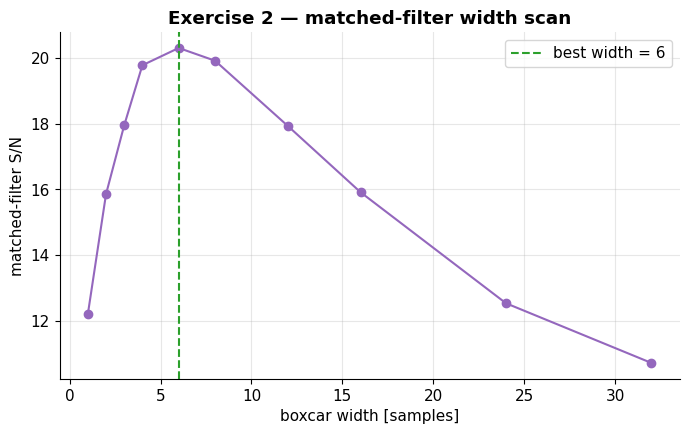

In [15]:
# TODO: de-disperse dynspec_x at the recovered DM and find the best boxcar width.
ts_x = dedisperse(dynspec_x, freqs, res_x.best_dm, dt)
widths_x = np.array([1, 2, 3, 4, 6, 8, 12, 16, 24, 32])
best_snr_x, best_w_x, _ = boxcar_snr(ts_x, widths_x)
snr_curve_x = np.array([boxcar_snr(ts_x, [w])[0] for w in widths_x])
print(
    f"injected sigma {width_x} samples -> best boxcar width {best_w_x} samples "
    f"(S/N {best_snr_x:.1f})"
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(widths_x, snr_curve_x, "o-", color="#9467bd")
ax.axvline(best_w_x, color="#2ca02c", ls="--", label=f"best width = {best_w_x}")
ax.set_xlabel("boxcar width [samples]")
ax.set_ylabel("matched-filter S/N")
ax.set_title("Exercise 2 — matched-filter width scan")
ax.legend()
plt.show()

<details>
<summary>Solution</summary>

**Does the best boxcar recover the injected width?** Not the Gaussian *sigma*
directly — it recovers something close to the pulse's **full width**. The burst
was injected as a Gaussian of $\sigma = $ `width_x` $= 2$ samples; a Gaussian's
full-width-at-half-maximum is

$$
\mathrm{FWHM} = 2\sqrt{2\ln 2}\,\sigma \approx 2.355\,\sigma \approx 4.7\ \text{samples}.
$$

The matched boxcar that maximises S/N comes out **slightly wider** than the FWHM,
because a top-hat capturing most of the Gaussian's *energy* (not just its half-max
core) is a touch broader. De-disperse at the recovered DM and scan the ladder:

```python
ts_x = dedisperse(dynspec_x, freqs, res_x.best_dm, dt)
widths_x = np.array([1, 2, 3, 4, 6, 8, 12, 16, 24, 32])
best_snr_x, best_w_x, _ = boxcar_snr(ts_x, widths_x)
print(best_w_x, best_snr_x)   # -> 6  20.3
```

With `amp_x = 8`, the scan gives a broad, gently rounded maximum (the matched
filter is forgiving near the optimum):

| boxcar width (samples) | 1 | 2 | 3 | 4 | **6** | 8 | 12 | 16 |
|---|---|---|---|---|---|---|---|---|
| S/N | 12.2 | 15.9 | 17.9 | 19.8 | **20.3** | 19.9 | 17.9 | 15.9 |

The best width is **6 samples** (S/N ≈ 20.3) — just above the 4.7-sample FWHM, as
expected. Two takeaways the plot makes vivid:

- **Too narrow** (w = 1) you miss pulse energy; **too wide** (w = 32) you average
  in noise — both sides fall away, exactly the matched-filter trade-off from
  Section 4.
- The boxcar S/N (~20) is much higher than the de-dispersed *sample* peak: the
  filter averages the pulse over its width and beats down white noise by
  $\sqrt{w}$, which is the whole point of matched filtering. Because the optimum
  is *broad*, a coarse width ladder still gets you within a few percent of the
  best S/N.

</details>

### Exercise 3 — What does a non-dispersed RFI blip look like?

Build your own RFI blip with `disperse_pulse(..., dm=0.0, ...)` at a time of your
choosing, run `dm_search`, and confirm its butterfly peaks at **DM = 0**.
Then try a *partially* dispersed terrestrial signal (a small non-zero DM, say
20–50) — many real RFI sources are not perfectly DM = 0. How well does the DM-0
test separate it from a genuine DM = 500 FRB? This is the everyday judgement call
of single-pulse searching.

In [16]:
# TODO: make an RFI blip (dm=0) and a "sneaky" low-DM blip, and compare their
#       butterflies to the real burst's.
rfi_x = disperse_pulse(
    n_time=n_time,
    freqs_mhz=freqs,
    dm=0.0,
    dt=dt,
    t0_index=500,
    width_samples=3.0,
    amplitude=12.0,
    noise=1.0,
    seed=123,
)
sneaky = disperse_pulse(
    n_time=n_time,
    freqs_mhz=freqs,
    dm=30.0,
    dt=dt,
    t0_index=300,
    width_samples=3.0,
    amplitude=12.0,
    noise=1.0,
    seed=321,
)

for name, data in [("DM=0 RFI", rfi_x), ("DM=30 sneaky", sneaky)]:
    r = dm_search(data, freqs, dt, dm_trials)
    print(f"{name:14s}: butterfly peaks at DM = {r.best_dm:6.0f}  (S/N {r.best_snr:.1f})")
print("Compare to the real burst, which peaks near DM = 500.")

DM=0 RFI      : butterfly peaks at DM =      0  (S/N 191.6)


DM=30 sneaky  : butterfly peaks at DM =     30  (S/N 183.1)
Compare to the real burst, which peaks near DM = 500.


<details>
<summary>Solution</summary>

**Where do the butterflies peak?** Running `dm_search` on the supplied blips
(over `dm_trials = np.linspace(0, 1000, 401)`):

```python
for name, data in [("DM=0 RFI", rfi_x), ("DM=30 sneaky", sneaky)]:
    r = dm_search(data, freqs, dt, dm_trials)
    print(f"{name:14s}: peak DM = {r.best_dm:4.0f}  S/N = {r.best_snr:.1f}")
```

| signal | peak DM | peak S/N |
|---|---|---|
| DM = 0 RFI | **0** | 191.6 |
| DM = 30 "sneaky" | **30** | 183.1 |
| (real burst, Section 3) | 500 | 48.2 |

The pure RFI blip is brightest with **no** de-dispersion (`shift = 0` in every
channel), so its butterfly peaks hard at **DM = 0** and slides downhill — it never
obeyed the $\nu^{-2}$ law. Note its S/N (≈ 192) is *far higher* than the real
burst's (≈ 48): a DM = 0 vertical streak aligns perfectly with itself when summed
straight, so brightness alone is no guarantee of astrophysical origin — the
strongest "detection" in your pipeline is often the worst RFI.

**How well does the DM-0 test separate the sneaky signal?** A partially dispersed
terrestrial source (DM = 30) peaks at **DM = 30**, not 0 — a crude
"reject everything at DM = 0" cut would let it through. But it is still trivially
separable from a genuine extragalactic FRB:

- A real FRB has **DM ≈ 500** here (hundreds-to-thousands in the wild) — *vastly*
  above any plausible terrestrial, or even Galactic, value along most sightlines.
  A DM = 30 blip is nowhere near.
- The discriminating quantity is therefore not "DM = 0 exactly" but **DM far above
  the Milky Way maximum** for that line of sight (NE2001 / YMW16). A low-DM blip
  (0–50) sits squarely in the Galactic/terrestrial regime; an FRB sits an order of
  magnitude beyond it.

So in practice you do **not** test DM = 0; you test DM **well above the Galactic
contribution**, *and* you fold in the other two discriminators from Section 6
(does it behave like the sidereal sky? is it a point source in only some feeds?).
The DM threshold rejects the easy RFI; the sky-behaviour and point-source checks
catch the perytons that slip past it.

</details>

## Recap

- A **fast radio burst** is a single, millisecond, **extragalactic** flash with an
  enormous **dispersion measure** — the headline that it crossed billions of
  light-years of intergalactic plasma. From the **Lorimer burst (2007)** through
  **Thornton (2013)**, the **first repeater (Spitler 2016)**, and the **Galactic
  magnetar burst (CHIME/STARE2 2020)**, the field went from a single oddity to a
  cosmological population with at least one identified source class.
- Dispersion obeys the cold-plasma law $\Delta t = k_\mathrm{DM}\,\mathrm{DM}\,
  (\nu_\mathrm{lo}^{-2} - \nu_\mathrm{hi}^{-2})$; a burst traces a curved
  $\nu^{-2}$ **sweep** across the dynamic spectrum.
- With **no period to fold on**, FRBs are found by a **single-pulse DM search**:
  de-disperse at many trial DMs and read the **S/N-vs-DM "butterfly,"** which
  peaks at the true DM.
- A **boxcar matched filter** tuned to the unknown pulse width is the optimal
  detector for a top-hat pulse in white noise — too narrow misses signal, too
  wide adds noise.
- Subtracting the Milky Way DM and applying the **Macquart relation**
  $z \approx \mathrm{DM_{excess}}/900$ gives a rough redshift; FRBs in bulk
  **locate the universe's "missing baryons"** in the diffuse IGM. It is
  order-of-magnitude per burst — large scatter, unknown host DM.
- The **RFI discipline** is non-negotiable: a real burst disperses as $\nu^{-2}$
  (a sharp butterfly), behaves like the **sky** (sidereal rising and setting), and
  is a **point source** (only some feeds). The **perytons** (microwave ovens) are
  the field's permanent reminder to ask what a *local* source would look like.

### What's next

- **Chapter 13 (Pulsars)** is the prerequisite: same dispersion physics, but with
  a period to **fold** on. FRBs are what that machinery looks like when you get
  exactly one pulse.
- **Chapter 16 (Data Formats & the Ecosystem)** is where this scales up. The plain
  NumPy `dedisperse` / `dm_search` here is the teaching version of what **PRESTO**
  (`prepsubband`, `single_pulse_search.py`) and SETI-stack tools like
  **`turboSETI`** do across thousands of trial DMs on real GUPPI/filterbank data —
  the same butterfly, just at survey scale. See also the
  [field notes](../docs/field-notes.md) on PRESTO and the amateur FRB reach of
  STARE2-style horns.